<a href="https://colab.research.google.com/github/sivakrishnaps/AI-ML-session/blob/main/Modelling_Polynomial_Regression_to_EEG_Data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Introduction
This study investigates the neural modulation of two distinct brain regions during guided meditation. The dataset comprises electroencephalography (EEG) measurements collected during a neuroscience experiment where participants listened to a meditation guide
. The specific areas monitored were the right auditory cortex, which is dedicated to processing auditory sensations, and the prefrontal cortex, which governs executive function, planning, and consciousness
. The primary objective is to mathematically model the relationship between the meditation guide's voice (the audio signal) and the corresponding brain activity in these two regions
.

#Literature Review & Hypothesis
Previous understandings of brain functionality suggest different processing complexities depending on the region. Based on this, the researchers hypothesized that the auditory cortex (x
2
​
 ) is linearly related to the audio signal (y), given its direct role in sensory processing
. In contrast, a nonlinear relationship is predicted for the prefrontal cortex (x
1
​
 ), reflecting its involvement in complex, higher-order cognitive tasks
. This project tests this hypothesis by evaluating a candidate set of nonlinear polynomial regression models to identify the 'true' mathematical relationship
.

# Import required libraries

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

import warnings
warnings.filterwarnings('ignore')

# Template specific styling

In [ ]:
sns.set_theme(context='notebook',
              style='white',
              palette='deep',
              font='DejaVu Sans', # Changed font from 'Lucida Calligraphy'
              font_scale=1.5,
              color_codes=True,
              rc=None)
import matplotlib

plt.rcParams['figure.figsize'] = (14,8)
plt.rcParams['figure.facecolor'] = '#F0F8FF'
plt.rcParams['figure.titlesize'] = 'medium'
plt.rcParams['figure.dpi'] = 150
plt.rcParams['figure.edgecolor'] = 'green'
plt.rcParams['figure.frameon'] = True

plt.rcParams["figure.autolayout"] = True

plt.rcParams['axes.facecolor'] = '#F5F5DC'
plt.rcParams['axes.titlesize'] = 25
plt.rcParams["axes.titleweight"] = 'normal'
plt.rcParams["axes.titlecolor"] = 'Olive'
plt.rcParams['axes.edgecolor'] = 'pink'
plt.rcParams["axes.linewidth"] = 2
plt.rcParams["axes.grid"] = True
plt.rcParams['axes.titlelocation'] = 'center'
plt.rcParams["axes.labelsize"] = 20
plt.rcParams["axes.labelpad"] = 2
plt.rcParams['axes.labelweight'] = 1
plt.rcParams["axes.labelcolor"] = 'Olive'
plt.rcParams["axes.axisbelow"] = False
plt.rcParams['axes.xmargin'] = .2
plt.rcParams["axes.ymargin"] = .2

plt.rcParams["xtick.bottom"] = True
plt.rcParams['xtick.color'] = '#A52A2A'
plt.rcParams["ytick.left"] = True
plt.rcParams['ytick.color'] = '#A52A2A'
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.color'] = 'green'
plt.rcParams['grid.linestyle'] = '--'
plt.rcParams['grid.linewidth'] = .5
plt.rcParams['grid.alpha'] = .3

plt.rcParams['legend.loc'] = 'best'
plt.rcParams['legend.facecolor'] =  'NavajoWhite'
plt.rcParams['legend.edgecolor'] = 'pink'
plt.rcParams['legend.shadow'] = True
plt.rcParams['legend.fontsize'] = 20


plt.rcParams['font.family'] = 'DejaVu Sans' # Changed font from 'Lucida Calligraphy'
plt.rcParams['font.size'] = 14
plt.rcParams['figure.dpi'] = 150
plt.rcParams['figure.edgecolor'] = 'Blue'

# Load the dataset

In [ ]:
url = 'https://raw.githubusercontent.com/sijuswamy/A-modern-approach-to-Research/main/X.csv'
df = pd.read_csv(url)

# Time series plots

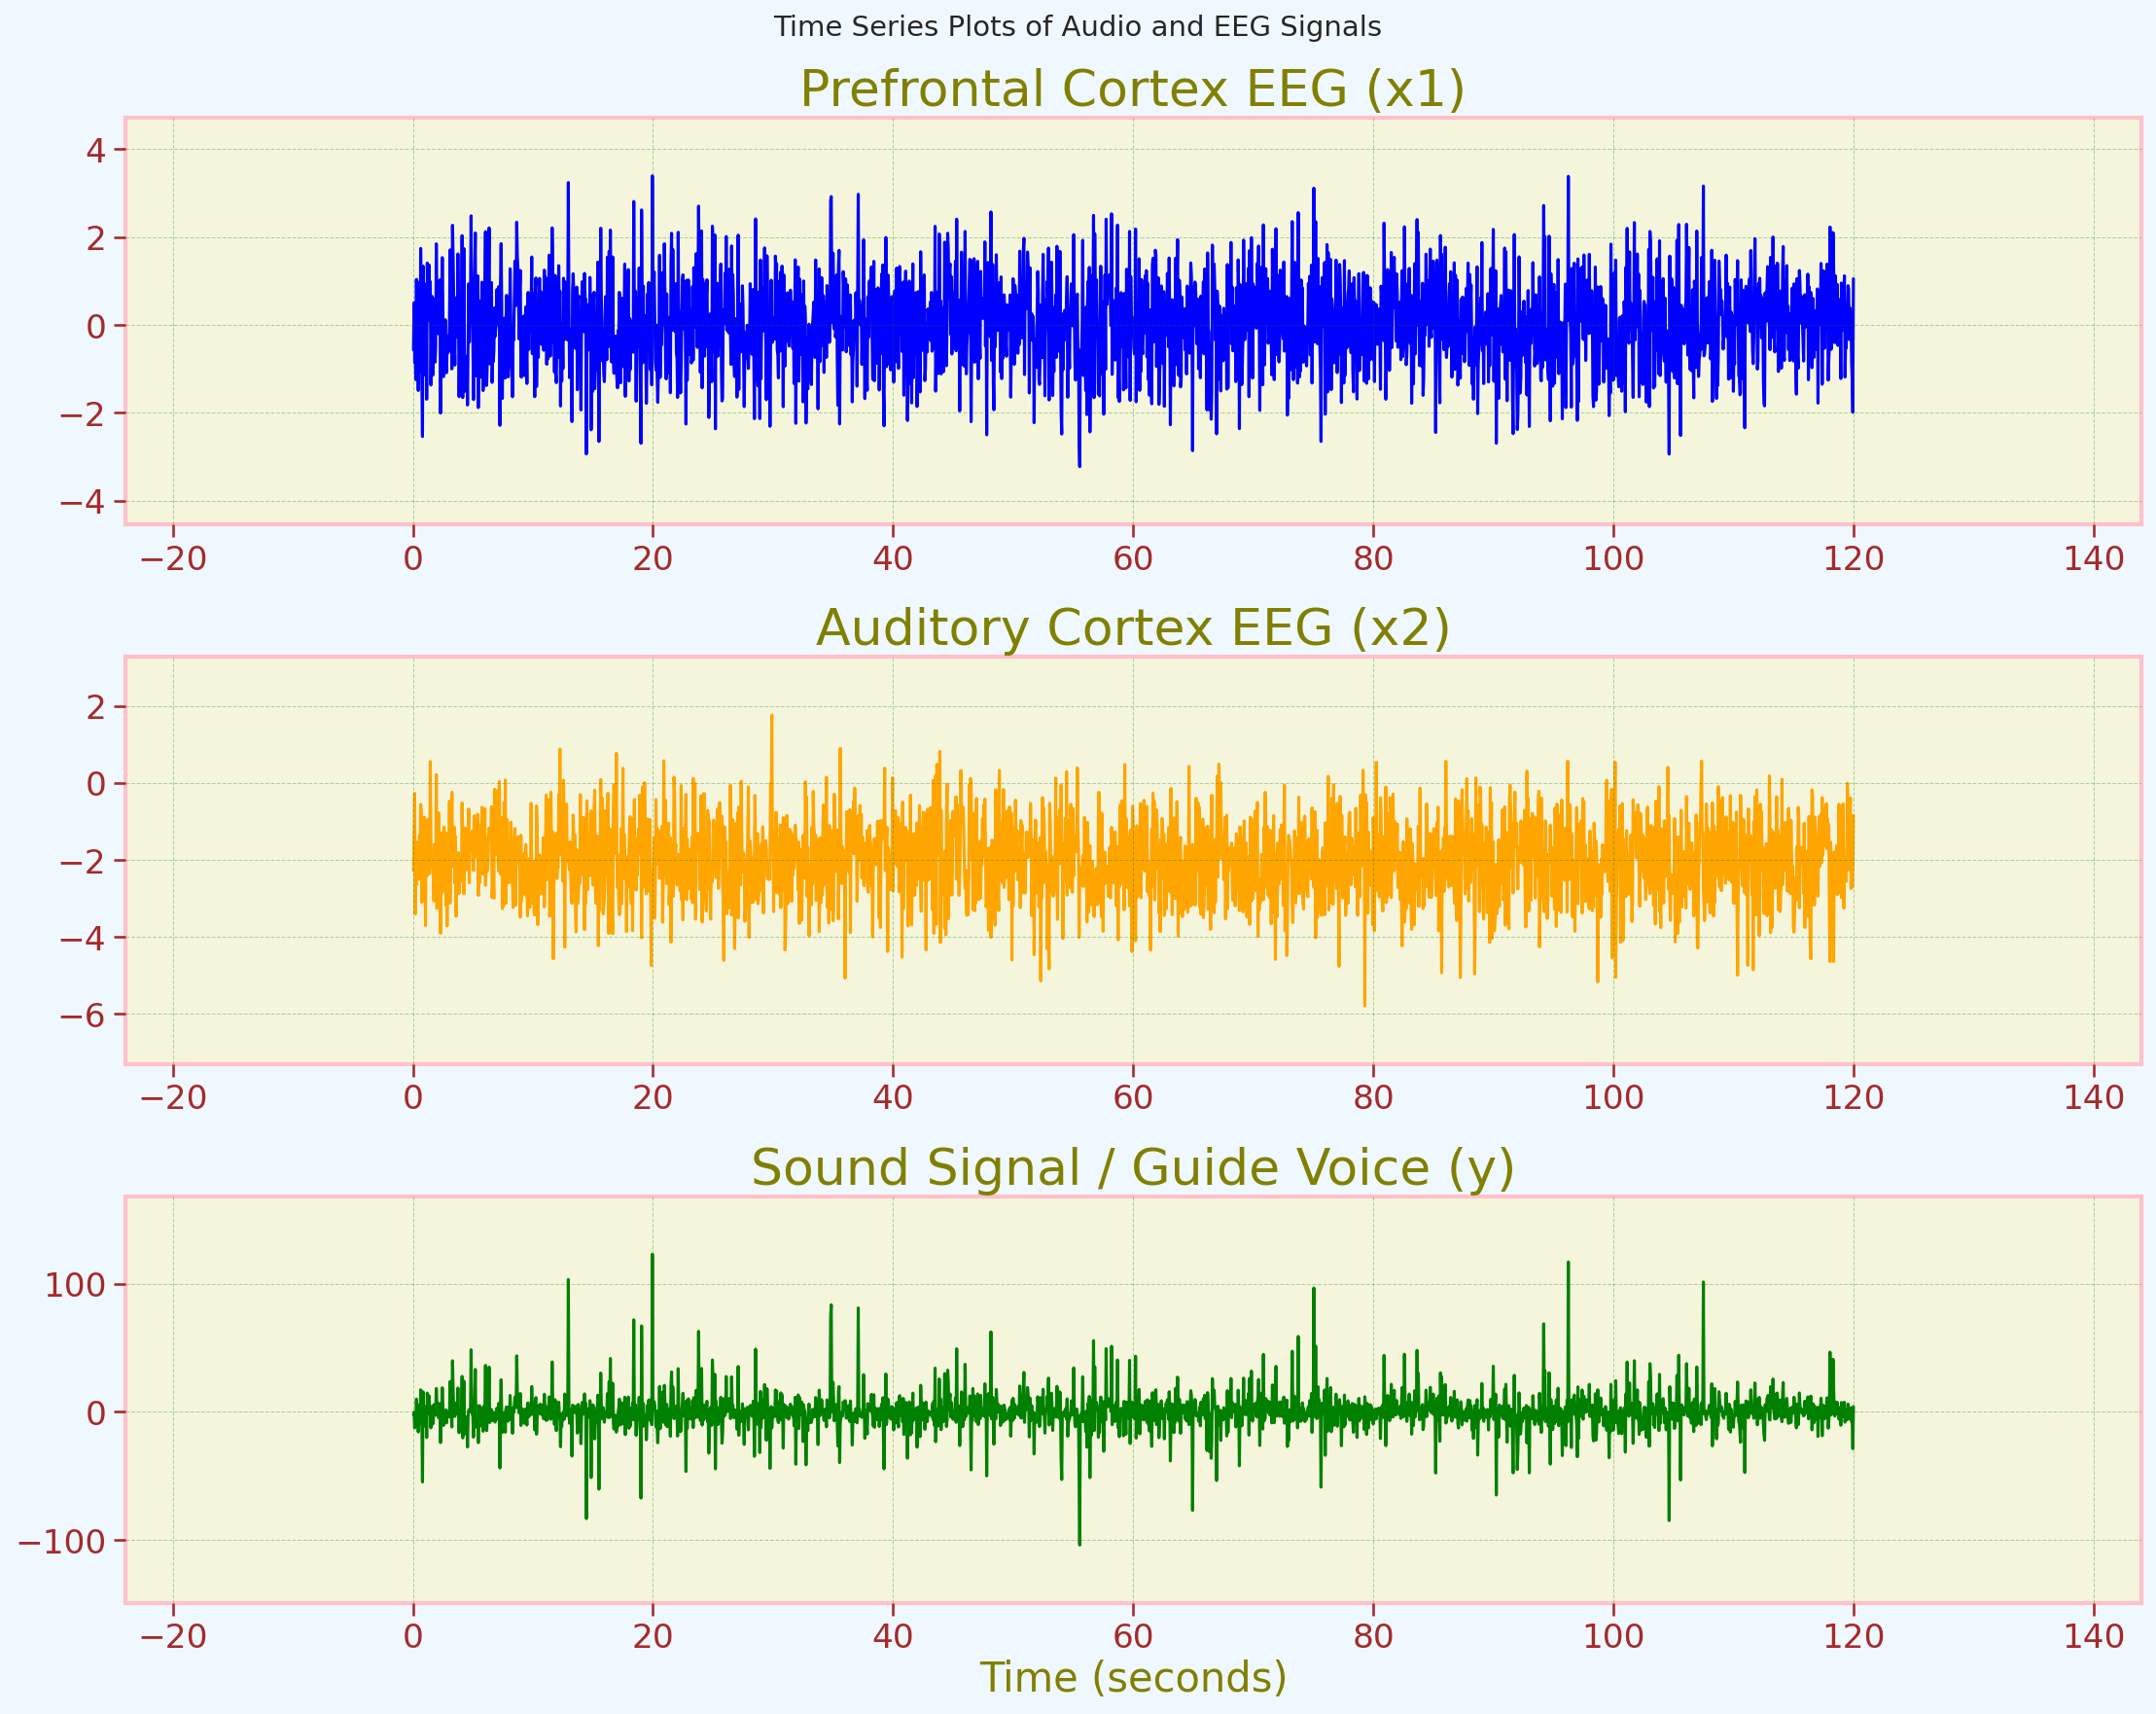

In [ ]:
fig, axes = plt.subplots(3, 1, figsize=(15, 12))
fig.suptitle('Time Series Plots of Audio and EEG Signals')

axes[0].plot(df['time'], df['x1'], color='blue')
axes[0].set_title('Prefrontal Cortex EEG (x1)')

axes[1].plot(df['time'], df['x2'], color='orange')
axes[1].set_title('Auditory Cortex EEG (x2)')

axes[2].plot(df['time'], df['y'], color='green')
axes[2].set_title('Sound Signal / Guide Voice (y)')
axes[2].set_xlabel('Time (seconds)')
plt.show()

# Distribution plots

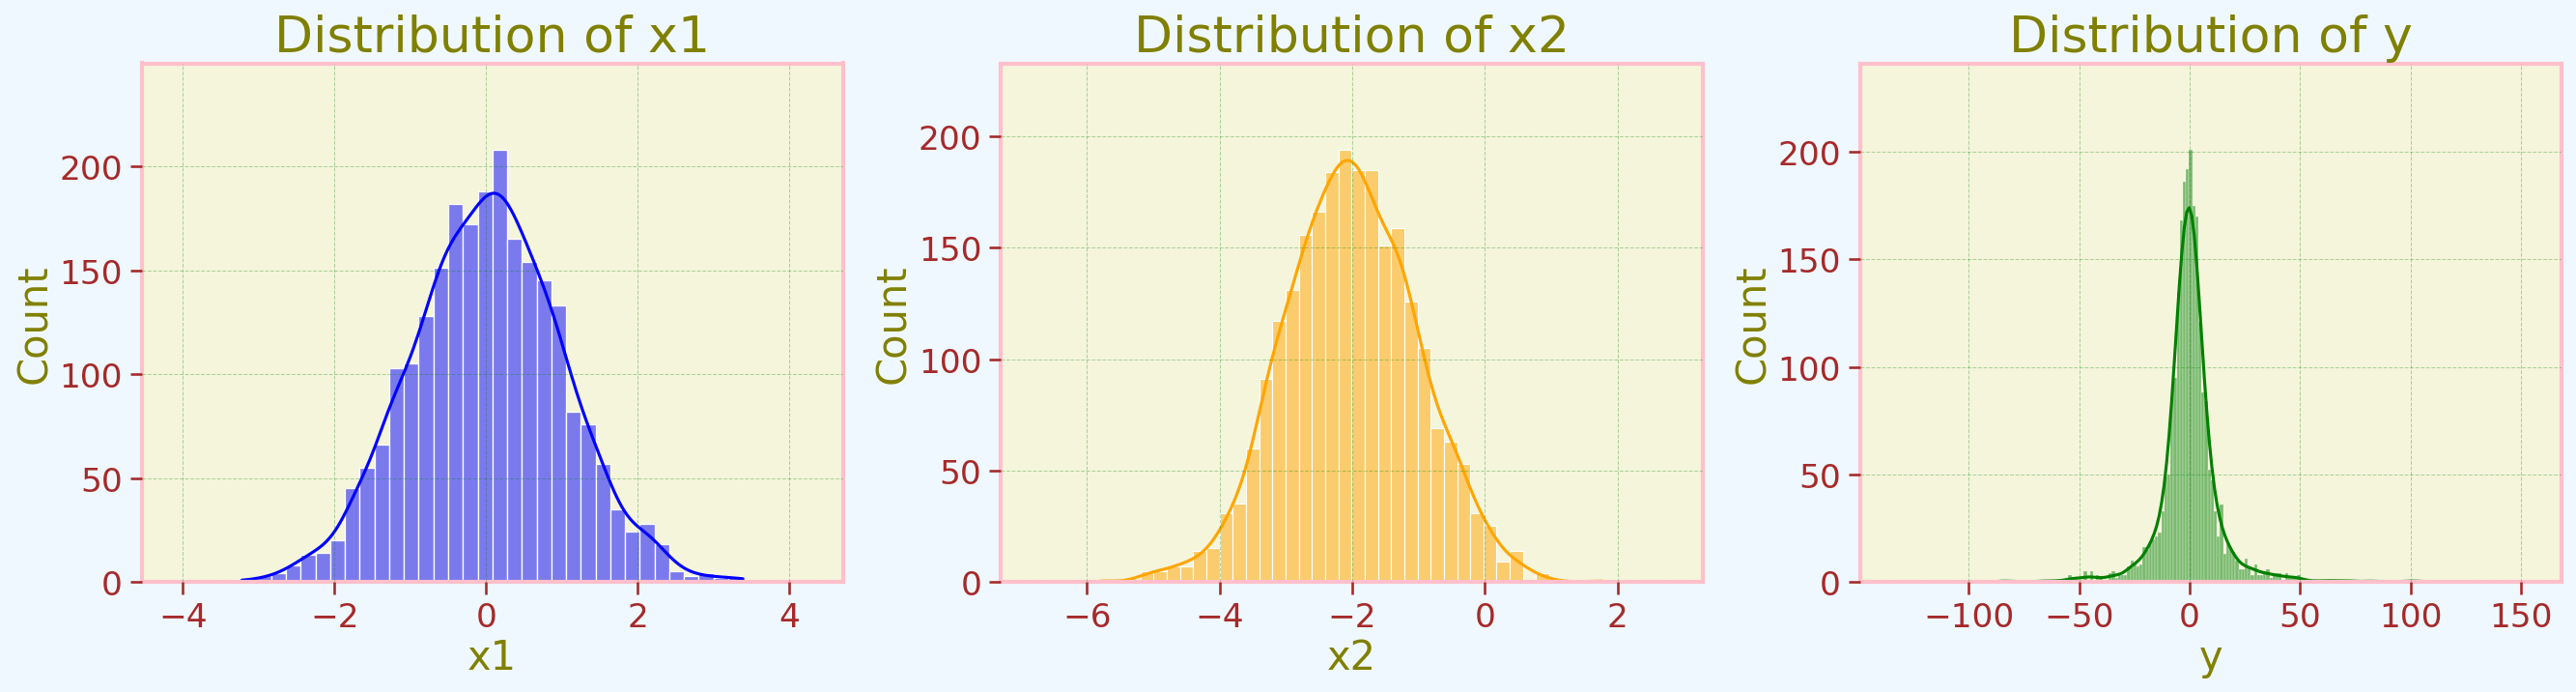

In [ ]:
# Distribution for each signal
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.histplot(df['x1'], kde=True, ax=axes[0], color='blue').set_title('Distribution of x1')
sns.histplot(df['x2'], kde=True, ax=axes[1], color='orange').set_title('Distribution of x2')
sns.histplot(df['y'], kde=True, ax=axes[2], color='green').set_title('Distribution of y')
plt.show()

# Correlation Analysis

,x1,x2,y
x1,1.000000,-0.024313,0.862507
x2,-0.024313,1.000000,-0.252638
y,0.862507,-0.252638,1.000000


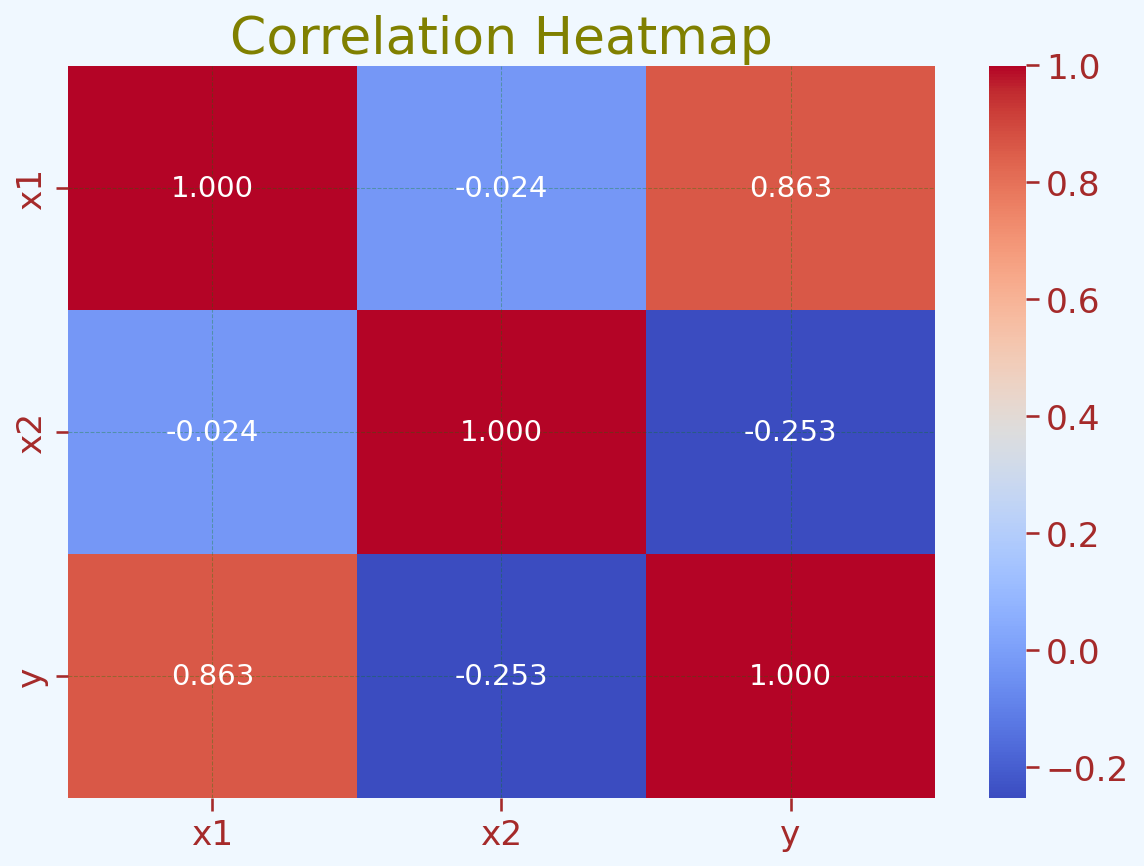

In [ ]:
# Correlation between the audio and brain signals
correlation_matrix = df[['x1', 'x2', 'y']].corr()
display(correlation_matrix)

plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".3f")
plt.title("Correlation Heatmap")
plt.show()

# Scatter plot

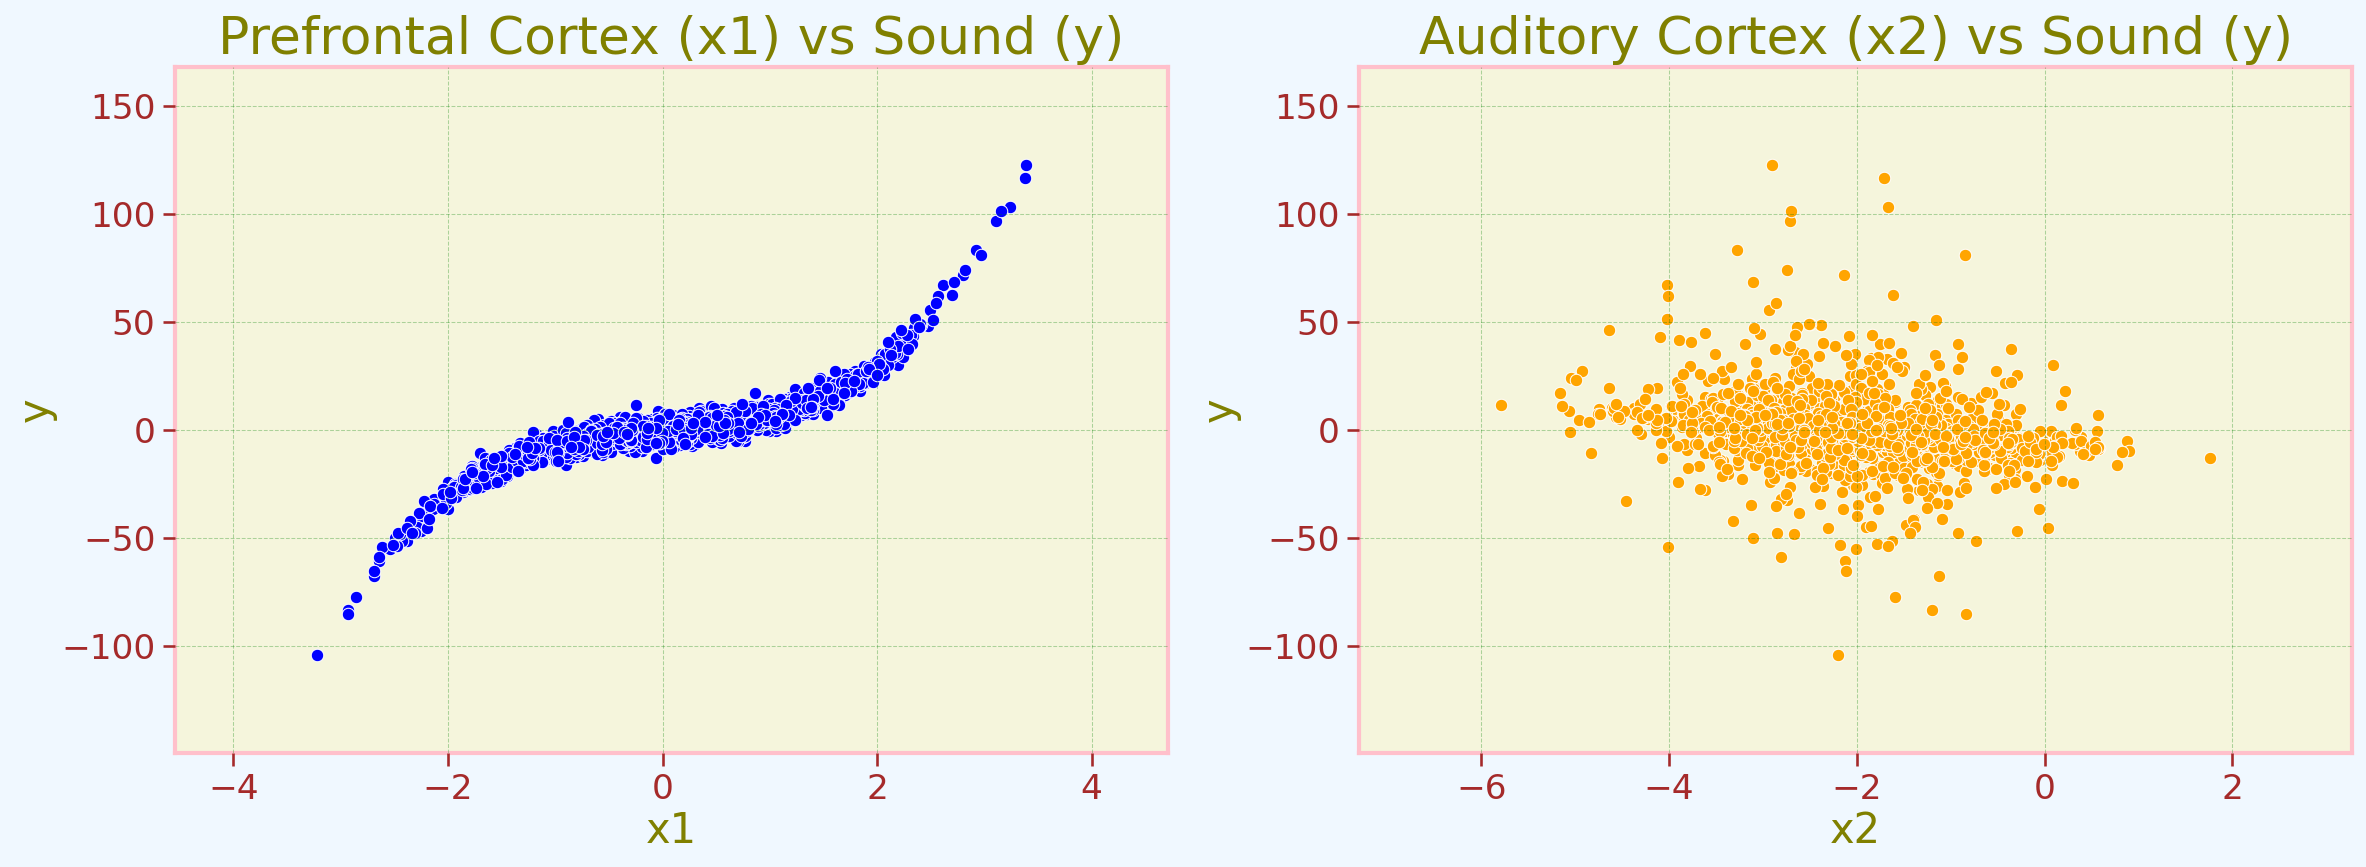

In [ ]:
# Scatter plots to examine dependencies
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.scatterplot(data=df, x='x1', y='y', ax=axes[0], color='blue').set_title('Prefrontal Cortex (x1) vs Sound (y)')
sns.scatterplot(data=df, x='x2', y='y', ax=axes[1], color='orange').set_title('Auditory Cortex (x2) vs Sound (y)')
plt.show()

In [ ]:
df.head()

,time,x1,x2,y
0,0.05,-0.562320,-2.274491,-2.386526
1,0.10,0.505550,-1.451586,-0.371560
2,0.15,-0.857812,-0.271215,-12.586452
3,0.20,-0.735262,-3.402501,-0.248121
4,0.25,-1.244369,-2.199162,-10.681437


#Methodology
To determine the most suitable mathematical model, we evaluated five specific candidate polynomial regression models that combine linear and nonlinear terms of the prefrontal cortex signal (x
1
​
 ) and the auditory cortex signal (x
2
​
 )
.
The parameters (θ) for each model were estimated using the Least Squares matrix method:  
θ
^
 =(X
T
 X)
−1
 X
T
 y
. The models were subsequently evaluated using the following statistical criteria
:


1.  Residual Sum of Squares (RSS): To measure the variance of the model's prediction errors.
2.   Log-likelihood function: To assess goodness of fit, assuming the additive noise is independent and identically distributed (i.i.d) Gaussian
.

3.   Akaike Information Criterion (AIC) & Bayesian Information Criterion (BIC): To identify the optimal model by balancing goodness-of-fit against model complexity (penalizing models with a higher number of parameters, k)
.
4.   Q-Q Plots: To visually verify that the model prediction errors (residuals) closely follow a Normal/Gaussian distribution
.





#Define the variables and construct the design matrices for all 5 candidate models

In [ ]:
import statsmodels.api as sm
import scipy.stats as stats

# Assign variables
y = df['y'].values
x1 = df['x1'].values
x2 = df['x2'].values
n = len(df)

# Define Design Matrices for all 5 candidate models
X1 = np.column_stack((x1**3, x2**5, np.ones(n)))
X2 = np.column_stack((x1**4, x2**2, np.ones(n)))
X3 = np.column_stack((x1**3, x2, x1, np.ones(n)))
X4 = np.column_stack((x1, x1**2, x1**3, x2**3, np.ones(n)))
X5 = np.column_stack((x1**3, x1**4, x2, np.ones(n)))

models = {'Model 1': X1, 'Model 2': X2, 'Model 3': X3, 'Model 4': X4, 'Model 5': X5}
model_metrics = []
model_residuals = {}

#Compute the Direct OLS, statsmodels OLS, and the Residual Sum of Squared Errors (RSS) for each model

In [ ]:
# Compute OLS and RSS
for name, X in models.items():
    k = X.shape[1] # Number of parameters

    # Direct OLS Matrix Method
    theta_hat = np.linalg.inv(X.T @ X) @ X.T @ y

    # Statsmodels OLS (Task 2.1 Verification)
    sm_model = sm.OLS(y, X).fit()

    # Model Residual Sum of Squared Errors (RSS)
    y_pred = X @ theta_hat
    residuals = y - y_pred
    RSS = np.sum(residuals**2)

    # Store data for the next steps
    model_residuals[name] = residuals
    model_metrics.append({'Model': name, 'k': k, 'RSS': RSS})

#Compute the Log-likelihood, AIC, and BIC

In [ ]:
# Compute Log-likelihood, AIC, and BIC
for metric in model_metrics:
    RSS = metric['RSS']
    k = metric['k']

    # Log-likelihood
    sigma_sq_hat = RSS / n
    log_likelihood = -(n/2)*np.log(2*np.pi) - (n/2)*np.log(sigma_sq_hat) - (1/(2*sigma_sq_hat))*RSS

    # AIC and BIC
    AIC = 2*k - 2*log_likelihood
    BIC = k*np.log(n) - 2*log_likelihood

    metric.update({'Log-Likelihood': log_likelihood, 'AIC': AIC, 'BIC': BIC})

results_df = pd.DataFrame(model_metrics)

#Check the distribution of model prediction errors using Q-Q plots to evaluate if they are close to Gaussian noise


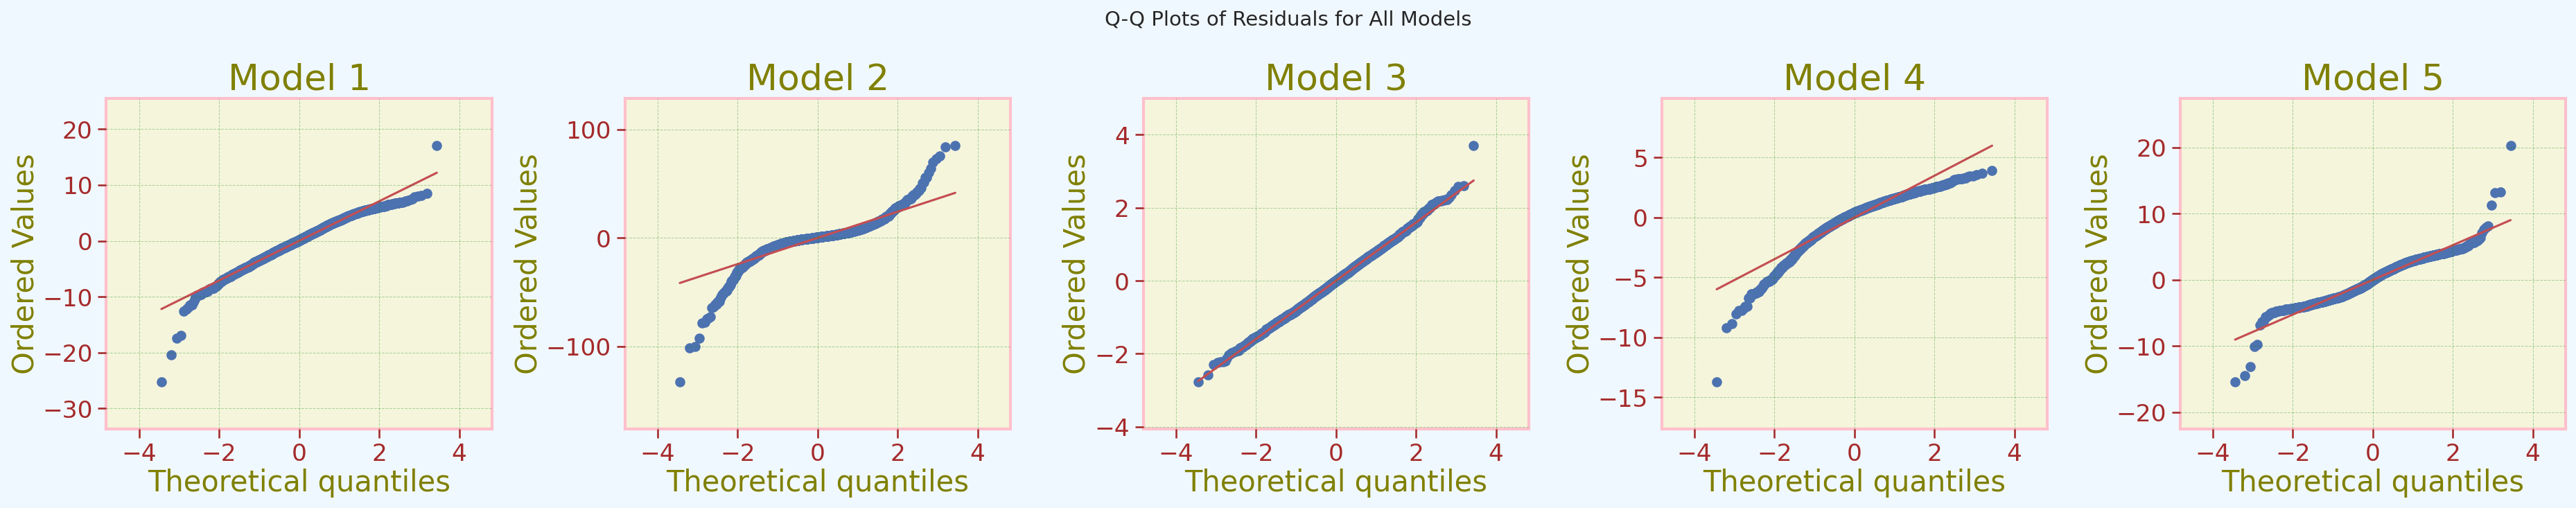

In [ ]:
# Q-Q Plots for Residuals
fig, axes = plt.subplots(1, 5, figsize=(25, 5))
fig.suptitle('Q-Q Plots of Residuals for All Models')

for idx, (name, residuals) in enumerate(model_residuals.items()):
    stats.probplot(residuals, dist="norm", plot=axes[idx])
    axes[idx].set_title(name)

plt.tight_layout()
plt.show()

In [ ]:
# Display final results for Task 2
display(results_df)

,Model,k,RSS,Log-Likelihood,AIC,BIC
0,Model 1,3,30738.220491,-6465.498212,12936.996424,12954.346096
1,Model 2,3,438230.352515,-9654.183624,19314.367248,19331.716920
2,Model 3,4,1525.621344,-2861.772114,5731.544227,5754.677123
3,Model 4,5,7949.272802,-4842.586538,9695.173077,9724.089197
4,Model 5,4,17138.098088,-5764.454727,11536.909455,11560.042351


#Summary of Findings
The preliminary exploratory data analysis revealed distinct interaction patterns. The correlation matrix indicated that the prefrontal cortex EEG (x
1
​
 ) shares a strong positive correlation with the audio signal (y) at approximately 0.86, whereas the auditory cortex EEG (x
2
​
 ) exhibits a weak negative correlation of -0.25
.

Upon evaluating the five candidate regression models, the calculated metrics clearly differentiated the models' performance
:


*   Model 1: AIC = 12936.99 | BIC = 12954.34

*   Model 2: AIC = 19314.36 | BIC = 19331.71

*   Model 3: AIC = 5731.54 | BIC = 5754.67
*   Model 4: AIC = 9695.17 | BIC = 9724.08


*   Model 5: AIC = 11536.90 | BIC = 11560.04

Model 3 achieved the lowest RSS (1525.62) and substantially lower AIC and BIC values compared to all other candidates
. Furthermore, the Q-Q plots indicated that the residuals for Model 3 most closely aligned with a normal distribution, satisfying the project's assumption of additive Gaussian noise
.

#Conclusions
Based on the quantitative analysis, Model 3 (y=θ
1
​
 x
1
3
​
 +θ
2
​
 x
2
​
 +θ
3
​
 x
1
​
 +θ
bias
​
 +ϵ) is unequivocally the best regression model to describe the evoked brain responses
. It provides the most optimal balance of accuracy and simplicity, as evidenced by possessing the lowest AIC and BIC scores
.

Crucially, the selection of Model 3 directly validates the researchers' initial hypothesis. In the structure of Model 3, the auditory cortex variable (x
2
​
 ) appears exclusively as a linear term (θ
2
​
 x
2
​
 )
. Conversely, the prefrontal cortex variable (x
1
​
 ) is modeled as a nonlinear polynomial encompassing a cubic term (θ
1
​
 x
1
3
​
 ) alongside a linear term
. Consequently, this mathematical modeling successfully proves that the auditory cortex responds linearly to the meditation guide's voice, while the prefrontal cortex engages in a more complex, nonlinear relationship, accurately reflecting its role in higher-order executive functions
.